In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler

# EDA

In [2]:
train_path = "train.csv"
test_path = "test.csv"
submission_path = "sample_submission.csv"

In [5]:
train = pd.read_csv(train_path)
test = pd.read_csv(test_path)
submission = pd.read_csv(submission_path)

In [6]:
print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")
print(f"Submission shape: {submission.shape}\n")

Train shape: (517754, 14)
Test shape: (172585, 13)
Submission shape: (172585, 2)



In [8]:
display(train.head())

,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
0,0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0.13
1,1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0.35
2,2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0.30
3,3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0.21
4,4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56


In [61]:
train['weather'].unique()

array(['rainy', 'clear', 'foggy'], dtype=object)

In [9]:
display(test.head())

,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents
0,517754,highway,2,0.34,45,night,clear,True,True,afternoon,True,True,1
1,517755,urban,3,0.04,45,dim,foggy,True,False,afternoon,True,False,0
2,517756,urban,2,0.59,35,dim,clear,True,False,afternoon,True,True,1
3,517757,rural,4,0.95,35,daylight,rainy,False,False,afternoon,False,False,2
4,517758,highway,2,0.86,35,daylight,clear,True,False,evening,False,True,3


In [18]:
display(submission.head(10))

,id,accident_risk
0,517754,0.352
1,517755,0.352
2,517756,0.352
3,517757,0.352
4,517758,0.352
5,517759,0.352
6,517760,0.352
7,517761,0.352
8,517762,0.352
9,517763,0.352


In [11]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517754 entries, 0 to 517753
Data columns (total 14 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      517754 non-null  int64  
 1   road_type               517754 non-null  object 
 2   num_lanes               517754 non-null  int64  
 3   curvature               517754 non-null  float64
 4   speed_limit             517754 non-null  int64  
 5   lighting                517754 non-null  object 
 6   weather                 517754 non-null  object 
 7   road_signs_present      517754 non-null  bool   
 8   public_road             517754 non-null  bool   
 9   time_of_day             517754 non-null  object 
 10  holiday                 517754 non-null  bool   
 11  school_season           517754 non-null  bool   
 12  num_reported_accidents  517754 non-null  int64  
 13  accident_risk           517754 non-null  float64
dtypes: bool(4), float64(

In [12]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 172585 entries, 0 to 172584
Data columns (total 13 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      172585 non-null  int64  
 1   road_type               172585 non-null  object 
 2   num_lanes               172585 non-null  int64  
 3   curvature               172585 non-null  float64
 4   speed_limit             172585 non-null  int64  
 5   lighting                172585 non-null  object 
 6   weather                 172585 non-null  object 
 7   road_signs_present      172585 non-null  bool   
 8   public_road             172585 non-null  bool   
 9   time_of_day             172585 non-null  object 
 10  holiday                 172585 non-null  bool   
 11  school_season           172585 non-null  bool   
 12  num_reported_accidents  172585 non-null  int64  
dtypes: bool(4), float64(1), int64(4), object(4)
memory usage: 12.5+ MB


In [13]:
print(train.isnull().sum().sort_values(ascending=False))

id                        0
road_type                 0
num_lanes                 0
curvature                 0
speed_limit               0
lighting                  0
weather                   0
road_signs_present        0
public_road               0
time_of_day               0
holiday                   0
school_season             0
num_reported_accidents    0
accident_risk             0
dtype: int64


In [14]:
print(test.isnull().sum().sort_values(ascending=False))

id                        0
road_type                 0
num_lanes                 0
curvature                 0
speed_limit               0
lighting                  0
weather                   0
road_signs_present        0
public_road               0
time_of_day               0
holiday                   0
school_season             0
num_reported_accidents    0
dtype: int64


In [15]:
display(train.describe())

,id,num_lanes,curvature,speed_limit,num_reported_accidents,accident_risk
count,517754.000000,517754.000000,517754.000000,517754.000000,517754.000000,517754.000000
mean,258876.500000,2.491511,0.488719,46.112575,1.187970,0.352377
std,149462.849975,1.120434,0.272563,15.788521,0.895961,0.166417
min,0.000000,1.000000,0.000000,25.000000,0.000000,0.000000
25%,129438.250000,1.000000,0.260000,35.000000,1.000000,0.230000
50%,258876.500000,2.000000,0.510000,45.000000,1.000000,0.340000
75%,388314.750000,3.000000,0.710000,60.000000,2.000000,0.460000
max,517753.000000,4.000000,1.000000,70.000000,7.000000,1.000000


In [21]:
num_cols = train.select_dtypes(include=[np.number]).columns
cat_cols = train.select_dtypes(exclude=[np.number]).columns

In [22]:
print(f"\nNumeric Columns ({len(num_cols)}): {list(num_cols)}")
print(f"Categorical Columns ({len(cat_cols)}): {list(cat_cols)}")


Numeric Columns (6): ['id', 'num_lanes', 'curvature', 'speed_limit', 'num_reported_accidents', 'accident_risk']
Categorical Columns (8): ['road_type', 'lighting', 'weather', 'road_signs_present', 'public_road', 'time_of_day', 'holiday', 'school_season']


In [25]:
if len(cat_cols) > 0:
    print("\nUnique Value Counts for All Categorical Columns (Train):")
    nunique_train = train[cat_cols].nunique().sort_values(ascending=False)
    display(nunique_train.to_frame("nunique_train"))

    print("\nUnique Value Counts for All Categorical Columns (Test):")
    nunique_test = test[cat_cols].nunique().sort_values(ascending=False)
    display(nunique_test.to_frame("nunique_test"))
else:
    print("\nNo categorical columns found.")


Unique Value Counts for All Categorical Columns (Train):


,nunique_train
road_type,3
lighting,3
weather,3
time_of_day,3
road_signs_present,2
public_road,2
holiday,2
school_season,2



Unique Value Counts for All Categorical Columns (Test):


,nunique_test
road_type,3
lighting,3
weather,3
time_of_day,3
road_signs_present,2
public_road,2
holiday,2
school_season,2


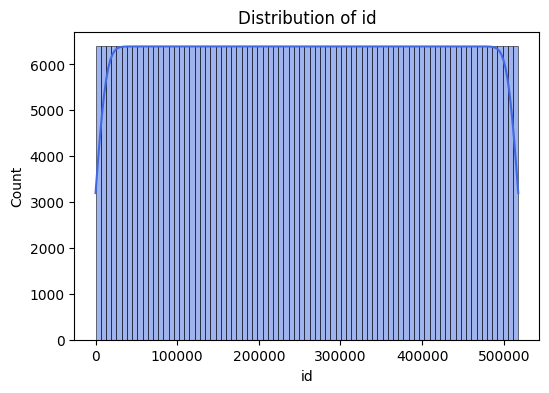

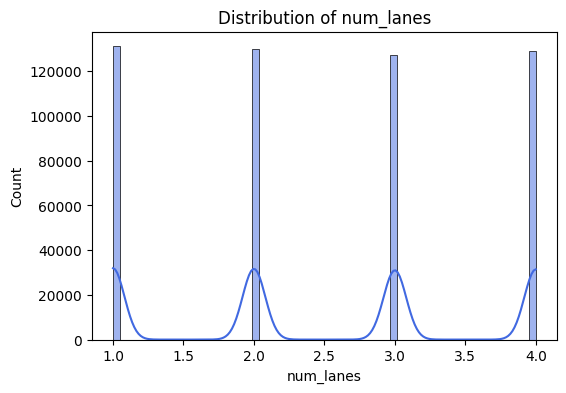

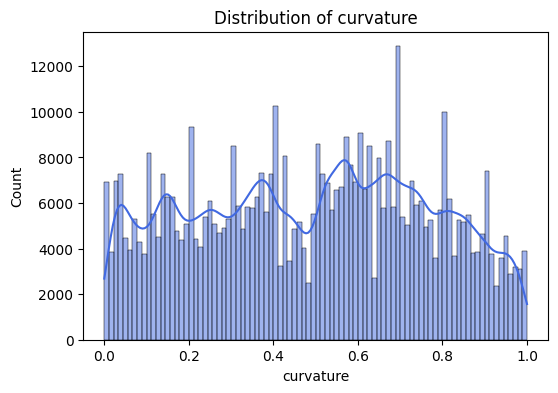

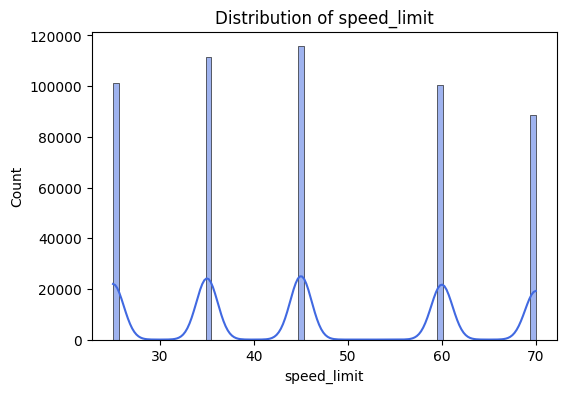

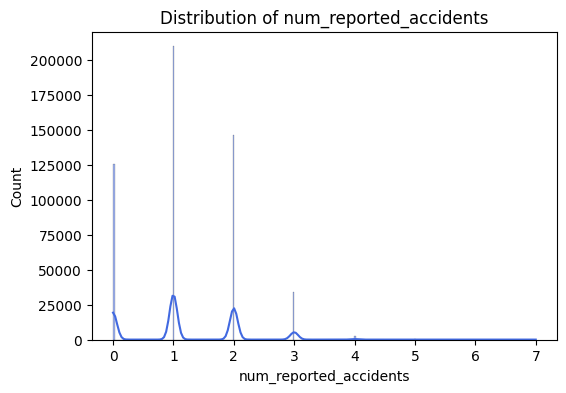

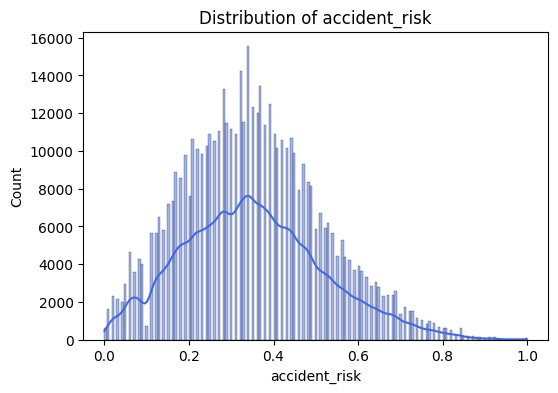

In [53]:
for col in num_cols[:6]:  # limit to first few columns for readability
    plt.figure(figsize=(6,4))
    sns.histplot(train[col], kde=True, color="royalblue")
    plt.title(f"Distribution of {col}")
    plt.show()

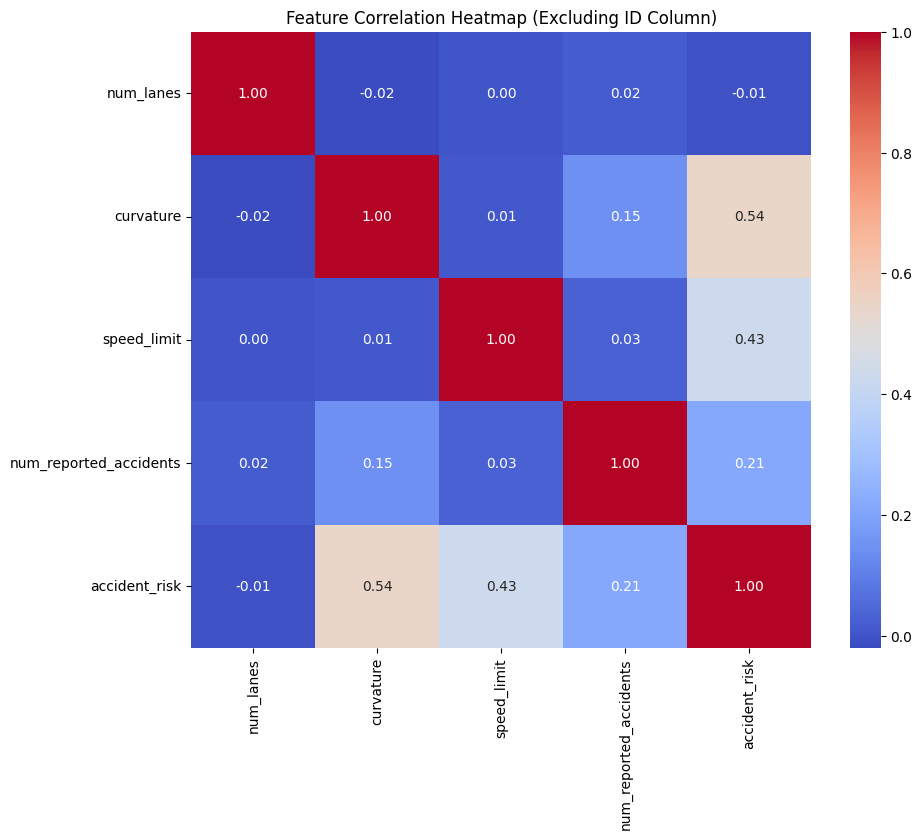

In [30]:
if len(num_cols) > 1:
    # Exclude the first numeric column (commonly an ID)
    corr_cols = num_cols[1:] if len(num_cols) > 1 else num_cols
    
    plt.figure(figsize=(10,8))
    sns.heatmap(train[corr_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Feature Correlation Heatmap (Excluding ID Column)")
    plt.show()


C:\Users\Miro Hernandez\AppData\Local\Temp\ipykernel_2864\543056565.py:5: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(train[col], label="Train", shade=True)
C:\Users\Miro Hernandez\AppData\Local\Temp\ipykernel_2864\543056565.py:6: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(test[col], label="Test", shade=True)


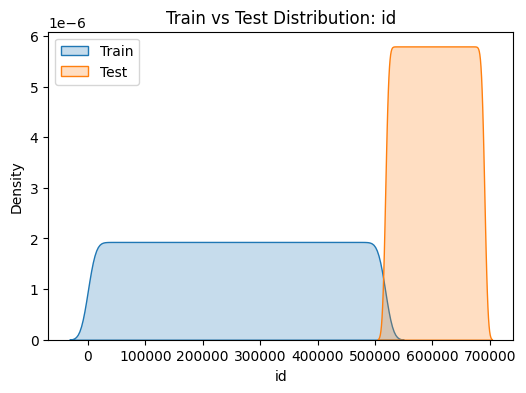

C:\Users\Miro Hernandez\AppData\Local\Temp\ipykernel_2864\543056565.py:5: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(train[col], label="Train", shade=True)
C:\Users\Miro Hernandez\AppData\Local\Temp\ipykernel_2864\543056565.py:6: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(test[col], label="Test", shade=True)


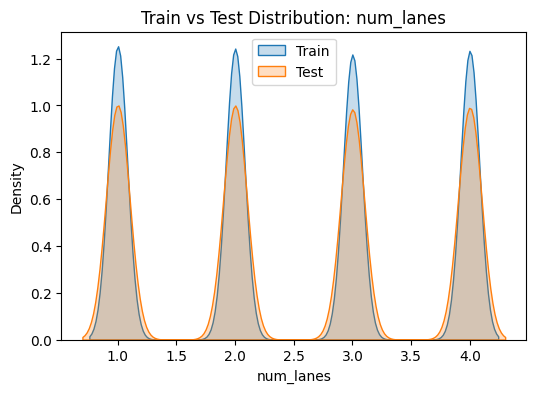

C:\Users\Miro Hernandez\AppData\Local\Temp\ipykernel_2864\543056565.py:5: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(train[col], label="Train", shade=True)
C:\Users\Miro Hernandez\AppData\Local\Temp\ipykernel_2864\543056565.py:6: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(test[col], label="Test", shade=True)


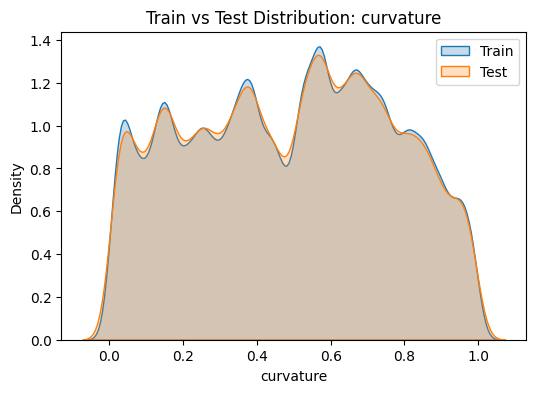

In [29]:
common_cols = [col for col in train.columns if col in test.columns]
for col in common_cols[:4]:
    if pd.api.types.is_numeric_dtype(train[col]):
        plt.figure(figsize=(6,4))
        sns.kdeplot(train[col], label="Train", shade=True)
        sns.kdeplot(test[col], label="Test", shade=True)
        plt.title(f"Train vs Test Distribution: {col}")
        plt.legend()
        plt.show()

In [32]:
target_col = "accident_risk"
cat_cols = [
    "road_type",
    "lighting",
    "weather",
    "road_signs_present",
    "public_road",
    "time_of_day",
    "holiday",
    "school_season"
]

In [33]:
anova_results = []

for col in cat_cols:
    # Drop NaNs
    df = train[[col, target_col]].dropna()

    # Group continuous target by each category
    groups = [group[target_col].values for name, group in df.groupby(col)]

    # Perform ANOVA only if we have at least 2 groups
    if len(groups) > 1:
        f_stat, p_value = stats.f_oneway(*groups)
        anova_results.append({
            "feature": col,
            "f_statistic": f_stat,
            "p_value": p_value
        })

# Convert results to DataFrame
anova_df = pd.DataFrame(anova_results).sort_values("p_value")

# Display sorted by significance
print("ANOVA F-test Results (sorted by significance):")
display(anova_df)

# Optional: highlight statistically significant features
sig_features = anova_df[anova_df["p_value"] < 0.05]["feature"].tolist()
print(f"\nSignificant features affecting {target_col}: {sig_features}")

ANOVA F-test Results (sorted by significance):


,feature,f_statistic,p_value
1,lighting,71752.063019,0.000000e+00
2,weather,10189.448768,0.000000e+00
6,holiday,1357.039313,1.106762e-296
4,public_road,499.079886,1.700501e-110
0,road_type,119.422083,1.404777e-52
5,time_of_day,26.388536,3.468873e-12
7,school_season,0.494096,4.821062e-01
3,road_signs_present,0.205090,6.506438e-01



Significant features affecting accident_risk: ['lighting', 'weather', 'holiday', 'public_road', 'road_type', 'time_of_day']


# Baseline Model

In [35]:
X = train.iloc[:, :-1]   # all except last column
y = train.iloc[:, -1]    # last column = accident_risk

In [36]:
X.shape

(517754, 13)

In [37]:
y.shape

(517754,)

In [41]:
categorical_cols = X.select_dtypes(include=["object", "bool"]).columns.tolist()
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
print(categorical_cols)
print(numeric_cols)

['road_type', 'lighting', 'weather', 'road_signs_present', 'public_road', 'time_of_day', 'holiday', 'school_season']
['id', 'num_lanes', 'curvature', 'speed_limit', 'num_reported_accidents']


In [42]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)


In [43]:
preprocessor

ColumnTransformer(transformers=[('cat',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore'),
                                 ['road_type', 'lighting', 'weather',
                                  'road_signs_present', 'public_road',
                                  'time_of_day', 'holiday', 'school_season']),
                                ('num', 'passthrough',
                                 ['id', 'num_lanes', 'curvature', 'speed_limit',
                                  'num_reported_accidents'])])

In [44]:
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

In [45]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [47]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['road_type', 'lighting',
                                                   'weather',
                                                   'road_signs_present',
                                                   'public_road', 'time_of_day',
                                                   'holiday',
                                                   'school_season']),
                                                 ('num', 'passthrough',
                                                  ['id', 'num_lanes',
                                                   'curvature', 'speed_limit',
                                                   'num_reported_accidents'])])),
                ('regressor', LinearRegression())])

In [49]:
y_pred = model.predict(X_val)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
r2 = r2_score(y_val, y_pred)

print("Baseline Linear Regression Results")
print(f"RMSE: {rmse:.4f}")
print(f"R_squared Score: {r2:.4f}")

Baseline Linear Regression Results
RMSE: 0.0735
R_squared Score: 0.8042


In [50]:
test_predictions = model.predict(test)

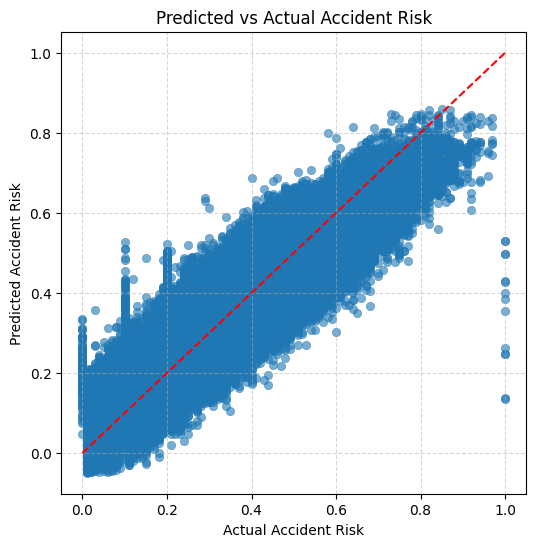

In [51]:
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_val, y=y_pred, alpha=0.6, edgecolor=None)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], color='red', linestyle='--')
plt.title("Predicted vs Actual Accident Risk")
plt.xlabel("Actual Accident Risk")
plt.ylabel("Predicted Accident Risk")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Feature Engineering 

In [83]:
scaler = MinMaxScaler()

In [84]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

In [85]:
train["scaled_speed_limit"] = scaler.fit_transform(train[["speed_limit"]])
test["scaled_speed_limit"] = scaler.transform(test[["speed_limit"]])

In [86]:
# a small epsilon to avoid divide-by-zero errors
epsilon = 1e-6
train["curvature_speed_product"] = train["curvature"] * (train["scaled_speed_limit"] + epsilon)
test["curvature_speed_product"] = test["curvature"] * (test["scaled_speed_limit"] + epsilon)

In [87]:
train[["curvature", "speed_limit", "scaled_speed_limit", "curvature_speed_product"]].head()

,curvature,speed_limit,scaled_speed_limit,curvature_speed_product
0,0.06,35,0.222222,0.013333
1,0.99,35,0.222222,0.220001
2,0.63,70,1.000000,0.630001
3,0.07,35,0.222222,0.015556
4,0.58,60,0.777778,0.451112


In [89]:
train["curvature_speed_product"].describe()

count    517754.000000
mean          0.230095
std           0.234275
min           0.000000
25%           0.030000
50%           0.155556
75%           0.368890
max           1.000001
Name: curvature_speed_product, dtype: float64

In [80]:
train["scaled_speed_limit"].describe()

count    517754.000000
mean          0.469168
std           0.350856
min           0.000000
25%           0.222222
50%           0.444444
75%           0.777778
max           1.000000
Name: scaled_speed_limit, dtype: float64

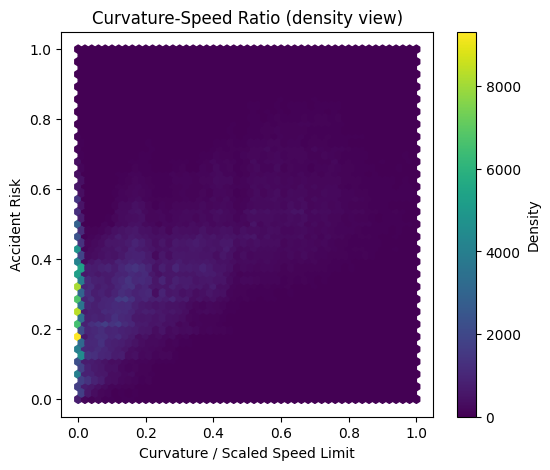

In [81]:
plt.figure(figsize=(6,5))
plt.hexbin(train["curvature_speed_ratio"], train["accident_risk"], gridsize=50, cmap="viridis")
plt.colorbar(label="Density")
plt.xlabel("Curvature / Scaled Speed Limit")
plt.ylabel("Accident Risk")
plt.title("Curvature-Speed Ratio (density view)")
plt.show()

In [91]:
train["scaled_num_lanes"] = scaler.fit_transform(train[["num_lanes"]])
test["scaled_num_lanes"] = scaler.transform(test[["num_lanes"]])

# 2. Create the product
train["lanes_speed_product"] = train["scaled_num_lanes"] * train["scaled_speed_limit"]
test["lanes_speed_product"] = test["scaled_num_lanes"] * test["scaled_speed_limit"]

# 3. Check distribution
print(train["lanes_speed_product"].describe())

count    517754.000000
mean          0.233413
std           0.279931
min           0.000000
25%           0.000000
50%           0.148148
75%           0.333333
max           1.000000
Name: lanes_speed_product, dtype: float64


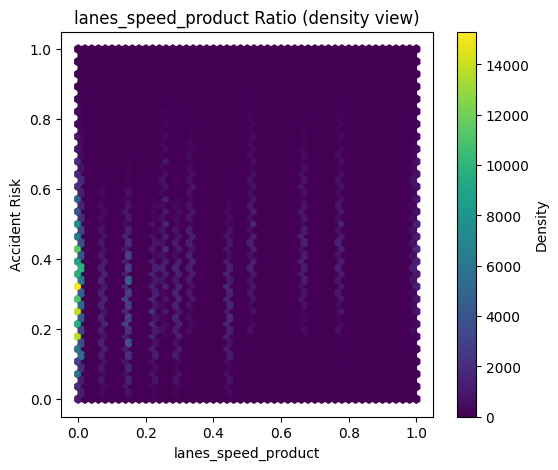

In [92]:
plt.figure(figsize=(6,5))
plt.hexbin(train["lanes_speed_product"], train["accident_risk"], gridsize=50, cmap="viridis")
plt.colorbar(label="Density")
plt.xlabel("lanes_speed_product")
plt.ylabel("Accident Risk")
plt.title("lanes_speed_product Ratio (density view)")
plt.show()

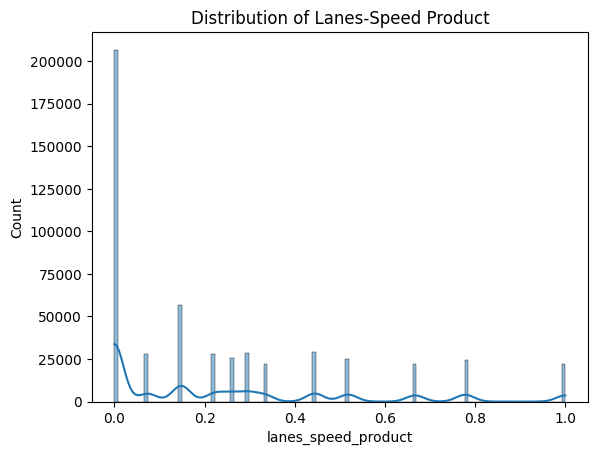

In [95]:
sns.histplot(train["lanes_speed_product"], kde=True)
plt.title("Distribution of Lanes-Speed Product")
plt.show()